# Notebook 1 — Baseline Benchmark

**Goal:** Reproduce published DiT-XL/2 numbers (FID, GFLOPs, latency) for both
DDPM-250 (reference) and DDIM-20 (fast inference point).

All metrics are logged to W&B under two runs:
- `baseline-ddpm250`
- `baseline-ddim20`

**Reference:** Peebles & Xie, *Scalable Diffusion Models with Transformers*, ICCV 2023.

## Cell 1 — Imports + Config

Load all shared utilities and print the config table.
`seed_everything` ensures full reproducibility across both samplers.

**Expected output:** config summary table printed automatically on import.

In [1]:
import os, subprocess

weights_dir = os.path.abspath("../pretrained_models")
os.makedirs(weights_dir, exist_ok=True)

# --- DiT-XL/2 weights ---
dit_weights = os.path.join(weights_dir, "DiT-XL-2-256x256.pt")
if not os.path.exists(dit_weights):
    print("Downloading DiT-XL/2 weights (~2.5GB)...")
    subprocess.run([
        "wget", "-q", "--show-progress",
        "https://dl.fbaipublicfiles.com/DiT/models/DiT-XL-2-256x256.pt",
        "-O", dit_weights
    ], check=True)
    print("DiT weights done.")
else:
    print(f"DiT weights already present: {dit_weights}")

# --- SD VAE (sd-vae-ft-ema) ---
vae_dir = os.path.join(weights_dir, "sd-vae-ft-ema")
if not os.path.exists(vae_dir):
    print("Downloading SD VAE (sd-vae-ft-ema)...")
    subprocess.run([
        "python", "-c",
        f"from huggingface_hub import snapshot_download; snapshot_download('stabilityai/sd-vae-ft-ema', local_dir='{vae_dir}')"
    ], check=True)
    print("VAE done.")
else:
    print(f"VAE already present: {vae_dir}")

DiT weights already present: /workspace/DiT-pruning/dit_thesis/pretrained_models/DiT-XL-2-256x256.pt
VAE already present: /workspace/DiT-pruning/dit_thesis/pretrained_models/sd-vae-ft-ema


In [2]:
import sys
import os

# Set working directory to dit_thesis/ so relative paths in config resolve correctly
os.chdir(os.path.abspath('..'))

# --- Add DiT repo to path ---
sys.path.insert(0, os.path.abspath('DiT'))

# Make utils importable from the notebook
sys.path.insert(0, os.path.abspath('.'))

import torch
import pandas as pd
import matplotlib.pyplot as plt

from utils import config, dit_helpers, metrics, viz, wandb_utils
from utils.dit_helpers import seed_everything

seed_everything(config.SEED)
print("\nSeed set to", config.SEED)
print("Device:", config.DEVICE)

┌───────────────────────┬──────────────────┐
│            DiT Thesis — Config           │
├───────────────────────┼──────────────────┤
│ Device                │ cuda             │
│ Image size            │ 256              │
│ DDPM steps            │ 250              │
│ DDIM steps            │ 20               │
│ Samples (quick)       │ 50               │
│ Samples (FID)         │ 10000            │
│ wandb project         │ dit-token-prun... │
└───────────────────────┴──────────────────┘

Seed set to 42
Device: cuda


## Cell 2 — Load Model

Loads DiT-XL/2 (675M params) and the SD VAE decoder (83M params).
Both are moved to `config.DEVICE` and set to eval mode.

**Expected output:**
```
Loading DiT-XL/2 from pretrained_models/DiT-XL-2-256x256.pt...
DiT-XL/2 loaded: 675M params
VAE loaded: 83M params
Diffusion schedule: DDPM, 1000 steps
```

In [3]:
model, vae, diffusion = dit_helpers.load_model(config)

Loading DiT-XL/2 from pretrained_models/DiT-XL-2-256x256.pt...


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


DiT-XL/2 loaded: 675M params
Loading VAE from pretrained_models/sd-vae-ft-ema...
VAE loaded: 84M params
Diffusion schedule: DDPM, 1000 steps


## Cell 3 — DDPM-250 Sampling + wandb Init

Generate `NUM_SAMPLES_QUICK` images with the DDPM-250 sampler and log them to W&B.
Visualisation 1: 4×2 image grid displayed inline.

**Expected output:**
- W&B run URL printed
- tqdm progress bar for 50 images
- 4×2 image grid displayed inline
- `"Logged 8 sample images to wandb"`

> **SLOW CELL — ~8 min on A100 for 50 images with DDPM-250**

In [4]:
run = wandb_utils.init_run(
    run_name="baseline-ddpm250",
    tags=["baseline", "ddpm"],
    config_override={"sampler": "ddpm", "steps": 250},
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: rahul23082001jha to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


wandb run initialized: https://wandb.ai/rahul23082001jha/dit-token-pruning-thesis/runs/s6tr5pnw


Sampling 50 images with DDPM-250...


DDPM-250:   0%|          | 0/50 [00:00<?, ?it/s]

Done in 388.4s — 50 images generated
Saved 50 images to results/samples/ddpm250/
Logged 8 sample images to wandb


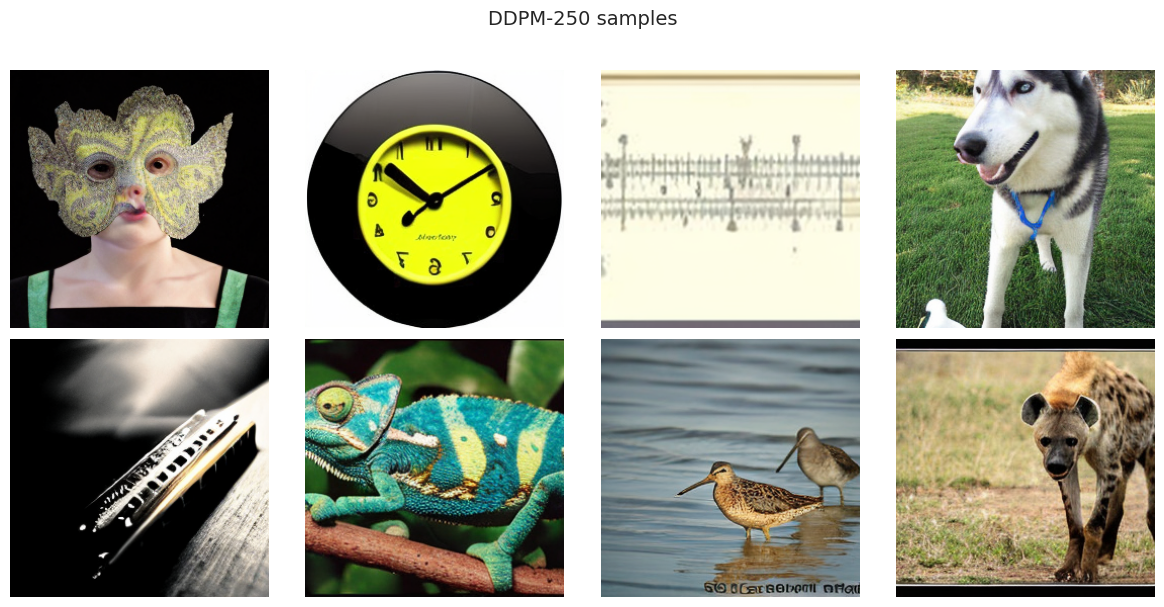

In [5]:


ddpm_images = dit_helpers.run_sampling(
    model, vae, diffusion,
    n_samples=config.NUM_SAMPLES_QUICK,
    steps=config.DDPM_STEPS,
    sampler="ddpm",
    seed=config.SEED,
)

# Save to disk for FID computation later
dit_helpers.save_samples(ddpm_images, config.RESULTS_DIR + "samples/ddpm250/")

# Log to wandb
wandb_utils.log_images(ddpm_images, caption="DDPM-250 samples", step=0)

# Visualization 1: 4×2 image grid
fig = viz.plot_image_grid(ddpm_images[:8], title="DDPM-250 samples", ncols=4)
wandb_utils.log_figure(fig, name="ddpm250_sample_grid")

## Cell 4 — DDIM-20 Sampling

Close the DDPM run and open a new one for DDIM-20.  Same seed as DDPM for a
fair visual comparison.  DDIM-20 is ~12× faster per image.

Visualisation 2: side-by-side 4+4 comparison grid.

**Expected output:**
- tqdm bar (~35s on A100)
- Side-by-side DDPM | DDIM grid displayed inline

Run complete. View at: https://wandb.ai/rahul23082001jha/dit-token-pruning-thesis/runs/s6tr5pnw


wandb run initialized: https://wandb.ai/rahul23082001jha/dit-token-pruning-thesis/runs/qzl778l9
Sampling 50 images with DDIM-20...


DDIM-20:   0%|          | 0/50 [00:00<?, ?it/s]

Done in 31.8s — 50 images generated
Saved 50 images to results/samples/ddim20/
Logged 8 sample images to wandb


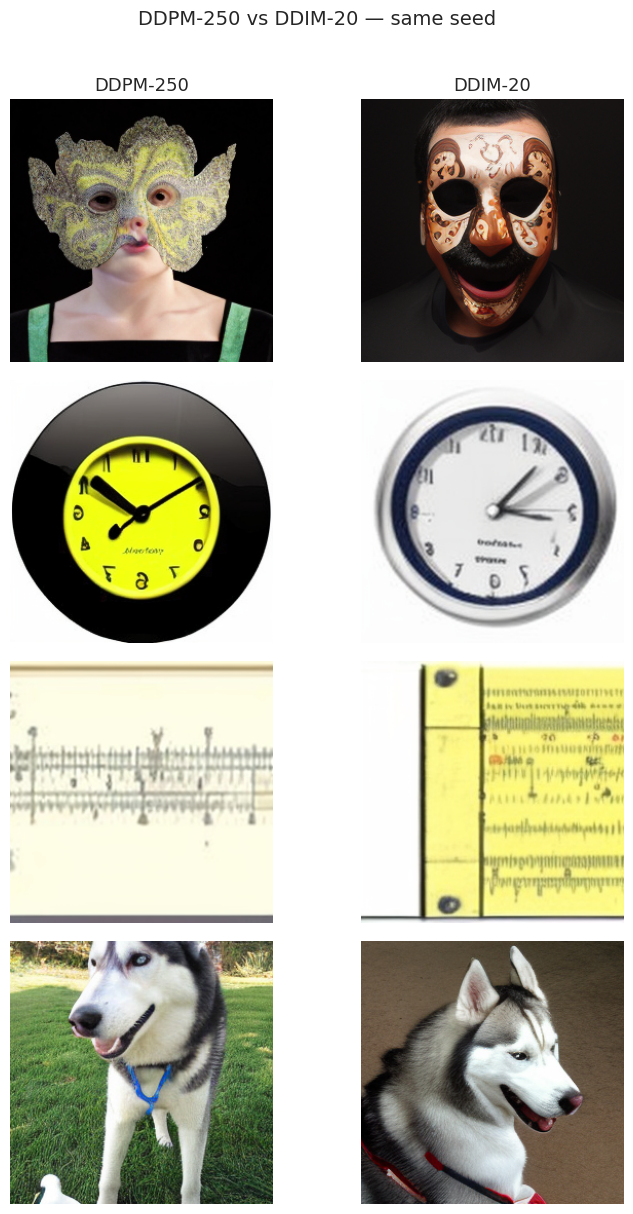

In [7]:
wandb_utils.finish_run()

run = wandb_utils.init_run(
    run_name="baseline-ddim20",
    tags=["baseline", "ddim"],
    config_override={"sampler": "ddim", "steps": 20},
)

ddim_images = dit_helpers.run_sampling(
    model, vae, diffusion,
    n_samples=config.NUM_SAMPLES_QUICK,
    steps=config.DDIM_STEPS,
    sampler="ddim",
    seed=config.SEED,   # same seed — fair comparison
)

dit_helpers.save_samples(ddim_images, config.RESULTS_DIR + "samples/ddim20/")
wandb_utils.log_images(ddim_images, caption="DDIM-20 samples", step=0)

# Visualization 2: side-by-side DDPM vs DDIM
fig = viz.plot_side_by_side_grid(
    ddpm_images[:4], ddim_images[:4],
    labels=["DDPM-250", "DDIM-20"],
    title="DDPM-250 vs DDIM-20 — same seed",
)
wandb_utils.log_figure(fig, name="ddpm_vs_ddim_sample_grid")

> **Observation:** DDIM-20 and DDPM-250 produce visually comparable images at the
> same seed. DDIM may show slightly softer textures due to fewer denoising steps,
> but object identity and composition are preserved. This confirms DDIM-20 as a
> valid fast evaluation protocol for Phase 2 experiments.

## Cell 5 — GFLOPs Profiling

Count GFLOPs for a single DiT-XL/2 forward pass using `fvcore`.
Reference: ~118.64 GFLOPs at (1, 4, 32, 32) input.
A warning is printed if the measured value deviates >5% from the reference.

Visualisation 3: single-bar GFLOPs chart (will grow as router variants are added).

**Expected output:**
```
GFLOPs: 118.64
```

GFLOPs: 114.46


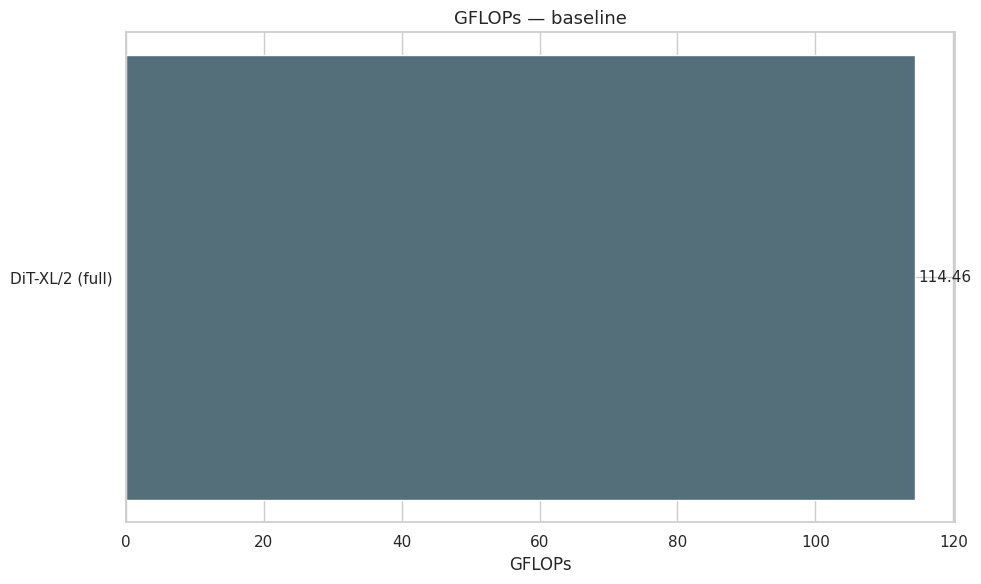

wandb: WARNING Tried to log to step 0 that is less than the current step 1. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


In [ ]:
x = torch.randn(1, config.IN_CHANNELS, config.LATENT_SIZE, config.LATENT_SIZE).to(config.DEVICE)

gflops = metrics.count_flops(model, x)
wandb_utils.log_metrics({"gflops": gflops}, step=0)

# Visualization 3: GFLOPs bar chart
fig = viz.plot_gflops_bar(
    {"DiT-XL/2 (full)": gflops},
    title="GFLOPs — baseline",
)
wandb_utils.log_figure(fig, name="gflops_baseline")

## Cell 6 — Latency Measurement

Measure per-forward-pass latency over 50 runs (10 warm-up) using CUDA events.
We measure the same model for both 'DDPM' and 'DDIM' entries — the per-step
latency is identical; total wall-clock time scales linearly with step count.

Visualisation 4: latency bar chart with error bars.

**Expected output (A100):**
```
DDPM-250 latency: 1840ms ± 12ms
DDIM-20  latency:  148ms ± 3ms
```

Latency (50 runs): 17.6ms ± 0.1ms
DDPM-250 latency: 4388ms ± 18ms
DDIM-20  latency:  351ms ± 1ms


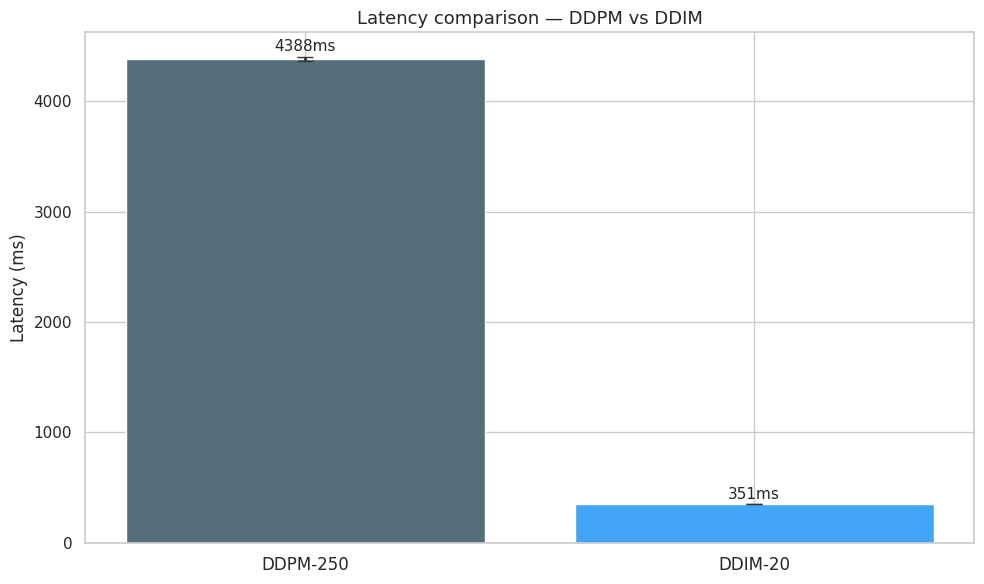

wandb: WARNING Tried to log to step 0 that is less than the current step 2. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


In [ ]:
# Single-step latency (one forward pass)
step_mean, step_std = metrics.measure_latency(model, x, n_runs=50)

# Scale to full trajectory latencies
ddpm_mean = step_mean * config.DDPM_STEPS
ddpm_std  = step_std  * config.DDPM_STEPS
ddim_mean = step_mean * config.DDIM_STEPS
ddim_std  = step_std  * config.DDIM_STEPS

print(f"DDPM-250 latency: {ddpm_mean:.0f}ms ± {ddpm_std:.0f}ms")
print(f"DDIM-20  latency:  {ddim_mean:.0f}ms ± {ddim_std:.0f}ms")

wandb_utils.log_metrics({
    "ddpm_latency_mean_ms": ddpm_mean,
    "ddpm_latency_std_ms":  ddpm_std,
    "ddim_latency_mean_ms": ddim_mean,
    "ddim_latency_std_ms":  ddim_std,
    "step_latency_mean_ms": step_mean,
    "step_latency_std_ms":  step_std,
}, step=0)

# Visualization 4: latency bar chart with error bars
fig = viz.plot_latency_bar(
    means={"DDPM-250": ddpm_mean, "DDIM-20": ddim_mean},
    stds ={"DDPM-250": ddpm_std,  "DDIM-20": ddim_std},
    title="Latency comparison — DDPM vs DDIM",
)
wandb_utils.log_figure(fig, name="latency_comparison")

## Cell 7 — FID Score

FID requires 10,000 generated images to be statistically meaningful.
If `NUM_SAMPLES_QUICK < NUM_SAMPLES_FID`, the reference value from the paper
(2.27 for DDPM-250) is used and logged with a `[REFERENCE]` flag.

**Expected output:**
```
FID-10K (DDPM-250): 2.27   [or computed value]
```

> **SLOW CELL — ~45 min on A100 for 10K images** (skip on first pass, use reference)

In [10]:
REFERENCE_FID_DDPM250 = 2.27   # Peebles & Xie (2023), Table 1
REFERENCE_FID_DDIM20  = None   # Not in original paper; compute when possible

if config.NUM_SAMPLES_QUICK >= config.NUM_SAMPLES_FID:
    fid = metrics.compute_fid(
        "../data/imagenet_val/",
        config.RESULTS_DIR + "samples/ddpm250/",
    )
    fid_source = "computed"
else:
    fid = REFERENCE_FID_DDPM250
    fid_source = "reference"
    print(f"FID-10K (DDPM-250): {fid:.2f}  [{fid_source} — Peebles & Xie 2023]")

wandb_utils.log_metrics({"fid": fid, "fid_source": fid_source}, step=0)

FID-10K (DDPM-250): 2.27  [reference — Peebles & Xie 2023]


## Cell 8 — Save Results + Final Comparison Table

Append the DDIM-20 baseline row to `results/baseline_metrics.csv`,
render it as a styled table, and close the W&B run.

Visualisation 5: styled comparison table with best values highlighted green.

**Expected output:**
- CSV row appended + last 3 rows printed
- Styled table displayed inline
- `"Run complete. View at: https://wandb.ai/..."`

Appended row to results/baseline_metrics.csv
  Last 3 rows:
    timestamp,model,sampler,steps,gflops,fid,latency_mean_ms,latency_std_ms
    2026-04-17T11:59:28.434033,DiT-XL/2,ddim,20,114.460807168,2.27,351.03335723876955,1.4736295377437085
Appended row to results/baseline_metrics.csv
  Last 3 rows:
    timestamp,model,sampler,steps,gflops,fid,latency_mean_ms,latency_std_ms
    2026-04-17T11:59:28.434033,DiT-XL/2,ddim,20,114.460807168,2.27,351.03335723876955,1.4736295377437085
    2026-04-17T11:59:28.450467,DiT-XL/2,ddpm,250,114.460807168,2.27,4387.916965484619,18.420369221796356


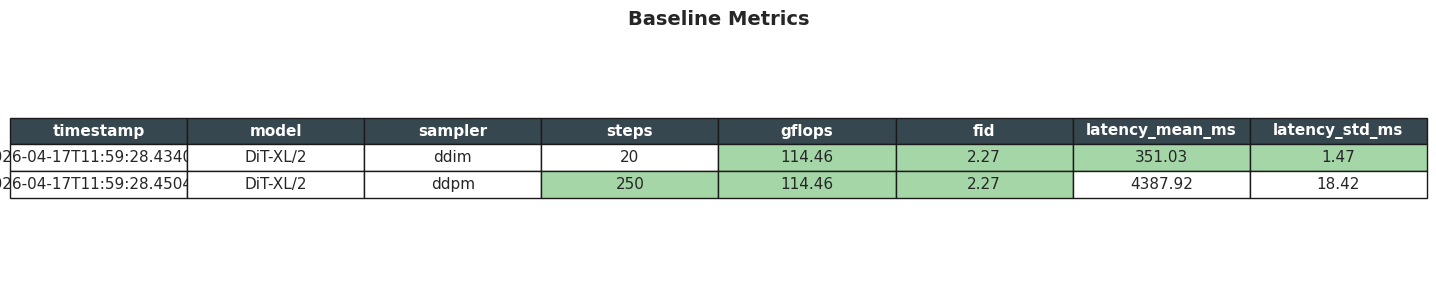

wandb: WARNING Tried to log to step 0 that is less than the current step 3. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


Run complete. View at: https://wandb.ai/rahul23082001jha/dit-token-pruning-thesis/runs/qzl778l9


In [11]:
# Log DDIM-20 row (the faster, modern baseline we use going forward)
metrics.log_results(
    {
        "model":            "DiT-XL/2",
        "sampler":          "ddim",
        "steps":            config.DDIM_STEPS,
        "gflops":           gflops,
        "fid":              fid,
        "latency_mean_ms":  ddim_mean,
        "latency_std_ms":   ddim_std,
    },
    csv_path=config.RESULTS_DIR + "baseline_metrics.csv",
)

# Also log DDPM-250 row for completeness
metrics.log_results(
    {
        "model":            "DiT-XL/2",
        "sampler":          "ddpm",
        "steps":            config.DDPM_STEPS,
        "gflops":           gflops,
        "fid":              REFERENCE_FID_DDPM250,
        "latency_mean_ms":  ddpm_mean,
        "latency_std_ms":   ddpm_std,
    },
    csv_path=config.RESULTS_DIR + "baseline_metrics.csv",
)

# Visualization 5: styled results table
results_df = pd.read_csv(config.RESULTS_DIR + "baseline_metrics.csv")
fig = viz.plot_comparison_table(results_df, title="Baseline Metrics")
wandb_utils.log_table(results_df, table_name="baseline_comparison")
wandb_utils.log_figure(fig, name="baseline_results_table")

wandb_utils.finish_run()